In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\hp\afficionado_forecasting\data\transactions.csv')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['revenue'] = df['transaction_qty']* df['unit_price']
df['hour'] =df['transaction_time'].dt.hour

print("Loaded:", df.shape)

Loaded: (149116, 13)


In [5]:
total_transactions = len(df)
print("Total transactions:", total_transactions)

print("Min transaction_id:", df['transaction_id'].min())
print("Max transaction_id:", df['transaction_id'].max())
print("Year values:", df['year'].unique())

print("Estimated avg per day:", total_transactions / 100)

Total transactions: 149116
Min transaction_id: 1
Max transaction_id: 149456
Year values: [2025]
Estimated avg per day: 1491.16


In [6]:
df_sorted = df.sort_values('transaction_id').reset_index(drop=True)
df_sorted['prev_hour'] = df_sorted['hour'].shift(1)
df_sorted['day_change'] = (df_sorted['hour'] < df_sorted['prev_hour'] - 5).astype(int)
df_sorted['day_number'] = df_sorted['day_change'].cumsum()

print("Number of unique days detected:", df_sorted['day_number'].nunique())
print("Transactions per day (sample):")
print(df_sorted.groupby('day_number').size().describe())

Number of unique days detected: 181
Transactions per day (sample):
count     181.000000
mean      823.845304
std       246.641752
min       459.000000
25%       597.000000
50%       753.000000
75%      1062.000000
max      1343.000000
dtype: float64


In [9]:
start_date = pd.Timestamp('2025-01-01')
df_sorted['date'] = start_date + pd.to_timedelta(df_sorted['day_number'], unit='D')
df_sorted['datetime'] = df_sorted['date'] + pd.to_timedelta(
    df_sorted['transaction_time'].dt.hour * 3600 +
    df_sorted['transaction_time'].dt.minute * 60 +
    df_sorted['transaction_time'].dt.second, unit='s'
)

print("Data range:", df_sorted['date'].min(), "to", df_sorted['date'].max())
print("Sample datetimes:")
print(df_sorted[['transaction_id','datetime','store_location','revenue']].head(10))

Data range: 2025-01-01 00:00:00 to 2025-06-30 00:00:00
Sample datetimes:
   transaction_id            datetime   store_location  revenue
0               1 2025-01-01 07:06:11  Lower Manhattan     6.00
1               2 2025-01-01 07:08:56  Lower Manhattan     6.20
2               3 2025-01-01 07:14:04  Lower Manhattan     9.00
3               4 2025-01-01 07:20:24  Lower Manhattan     2.00
4               5 2025-01-01 07:22:41  Lower Manhattan     6.20
5               6 2025-01-01 07:22:41  Lower Manhattan     3.00
6               7 2025-01-01 07:25:49  Lower Manhattan     2.00
7               8 2025-01-01 07:33:34  Lower Manhattan     4.00
8               9 2025-01-01 07:39:13  Lower Manhattan     4.25
9              10 2025-01-01 07:39:34  Lower Manhattan     7.00


Dailt time series shape: (543, 5)
        date   store_location  total_revenue  total_qty  num_transactions
0 2025-01-01          Astoria         868.40        277               190
1 2025-01-01   Hell's Kitchen         851.45        270               184
2 2025-01-01  Lower Manhattan         788.35        255               176
3 2025-01-02          Astoria         925.50        301               212
4 2025-01-02   Hell's Kitchen         828.80        272               195
5 2025-01-02  Lower Manhattan         649.05        217               159
6 2025-01-03          Astoria         902.75        287               205
7 2025-01-03   Hell's Kitchen         906.25        295               211
8 2025-01-03  Lower Manhattan         756.00        241               166


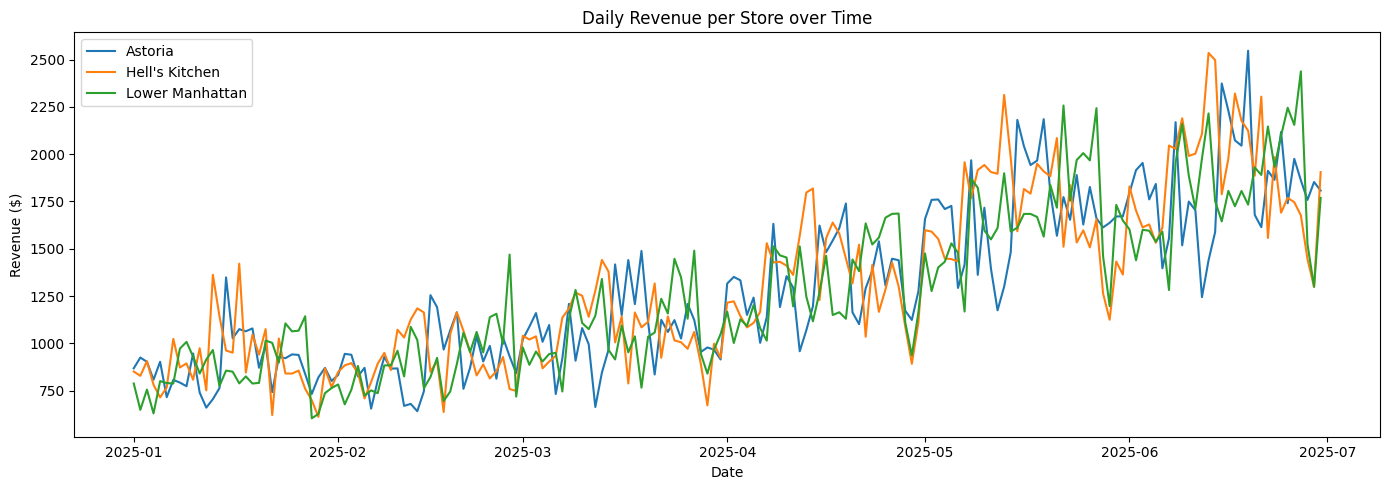

In [12]:
daily_ts = df_sorted.groupby(['date','store_location']).agg(
    total_revenue=('revenue','sum'),
    total_qty=('transaction_qty','sum'),
    num_transactions=('transaction_id','count')
).reset_index()

print("Dailt time series shape:", daily_ts.shape)
print(daily_ts.head(9))

fig, ax = plt.subplots(figsize=(14,5))
for store in daily_ts['store_location'].unique():
    store_data = daily_ts[daily_ts['store_location'] == store]
    ax.plot(store_data['date'], store_data['total_revenue'], label=store, linewidth=1.5)

ax.set_title('Daily Revenue per Store over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig('data/daily_revenue_timeseries.png')
plt.show()